# 통합 후 공선성 재검증 (`05_Collinearity_Recheck`)

```
01_Window_Definition → 02_Integrated_Table → 03_Landmark25_EDA → 04_Missing_Outlier → [05_Collinearity_Recheck] → 03_Modeling
```

> 2026-09-13 갱신: 통합 정본의 평가 기회·이월 정의 변경(`0913_01_assessment_opportunity_banked.md`)을 반영해 전체를 재실행했다.
> 추가 피처 `n_banked_25` 검증(4.5절)을 넣었고, 최종 피처는 19개 → **20개**가 됐다. 노트북 번호도 `04` → `05`로 바뀌었다(EDA 단계 삽입).

이 노트북은 `model_df_clean`(27,654행)의 **최종 모델 피처 목록을 확정**하는 단계다.
`work_process/reports/04_next_steps.md` P3에 해당한다.

점검 순서는 다음과 같다.

1. 피처 후보 정의와 누수 컬럼 배제 검증
2. 수치형 피처 상관행렬
3. 수학적 종속성 정리 — 평가 행동 5종, VLE 파생 플래그
4. 종속 파생을 제거한 뒤 VIF 재검증
5. 범주형 피처 간 연관성(Cramér's V)과 `gender` × `code_module` 문제
6. `code_presentation` 대신 `presentation_period` 파생
7. 최종 피처 목록과 제외 이유 확정

선행 문서:

- `work_process/decisions/preprocessing/0912_01_missing_value_policy.md` (결측 처리 방침)
- `work_process/decisions/preprocessing/0912_02_outlier_policy.md` (이상치 처리 방침)
- `work_process/decisions/modeling/0902_01_landmark_n25_final.md` (N=25 확정)
- `work_process/decisions/preprocessing/0913_01_assessment_opportunity_banked.md` (평가 기회·이월 정의)
- `Notebooks/02_Window_Integration/03_Landmark25_EDA.ipynb` (과목별 구조, 이월, 성별 교란)

## 1. 환경 설정 및 데이터 로드

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 그래프 한글 라벨 (기존 노트북과 동일한 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()

CLEAN_PATH = PROJECT_ROOT / 'CSV_files' / '통합 버전' / 'model_df_clean_n25.csv'
KEYS = ['code_module', 'code_presentation', 'id_student']

assert CLEAN_PATH.exists(), (
    f'정제 데이터가 없습니다: {CLEAN_PATH}\n'
    '먼저 04_Missing_Outlier.ipynb의 6.1절을 실행해 생성하세요.'
)
model_df_clean = pd.read_csv(CLEAN_PATH)

# 04 노트북의 결과와 동일한지 계약 재확인
assert len(model_df_clean) == 27_654, '행 수 불일치'
assert model_df_clean.duplicated(KEYS).sum() == 0, '키 중복 발생'
assert int(model_df_clean['target_churn_after_25'].sum()) == 5_246, '양성 건수 불일치'
assert model_df_clean['imd_band'].isna().sum() == 0, 'imd_band 결측 잔존'
assert 'n_banked_25' in model_df_clean.columns, '평가 기회·이월 정의 변경(0913_01) 전 데이터'

print('로드 경로:', CLEAN_PATH)
print('shape:', model_df_clean.shape)
print('양성 비율:', round(model_df_clean['target_churn_after_25'].mean(), 4))

로드 경로: C:\DA_WorkSpace\Personal_OULAD_Churn_Prediction\CSV_files\통합 버전\model_df_clean_n25.csv
shape: (27654, 30)
양성 비율: 0.1897


## 2. 피처 후보 정의와 누수 컬럼 배제

전체 29개 컬럼 중 **입력 피처가 될 수 없는 컬럼**을 먼저 제외한다. 제외 사유는 세 가지다.

| 사유 | 컬럼 |
|---|---|
| 식별자(그레인 키) | `id_student` |
| 상수(모델 대상 필터링 결과라 변별력 0) | `landmark_day`, `eligible_at_25`, `cohort_status_25` |
| **25일 이후 정보 = 누수** | `final_result`, `date_unregistration`, `target_churn_after_25` |

`code_module`·`code_presentation`은 개강 전에 확정되는 정보라 누수가 아니다. 다만
`code_presentation`은 7절에서 별도로 다룬다.

프로젝트 데이터 계약("N 이후의 클릭·제출·점수와 `final_result`, `date_unregistration`,
타깃 파생값은 입력 피처에서 제외")을 코드로 검증한다.

In [2]:
TARGET = 'target_churn_after_25'

ID_COLS = ['id_student']
CONST_COLS = ['landmark_day', 'eligible_at_25', 'cohort_status_25']
LEAK_COLS = ['final_result', 'date_unregistration', TARGET]

# 상수 컬럼 주장 검증: 모델 대상만 남았으므로 실제로 유일값 1개여야 한다
const_check = model_df_clean[CONST_COLS].nunique()
print('상수 주장 컬럼의 유일값 수:')
print(const_check)
assert (const_check == 1).all(), '상수라고 판단한 컬럼에 실제로는 여러 값이 존재'

# 누수 컬럼이 타깃과 결정적으로 얽혀 있음을 확인(배제 근거 기록용)
leak_evidence = pd.crosstab(
    model_df_clean['final_result'],
    model_df_clean[TARGET].rename('target_churn_after_25'),
)
print()
print('final_result × 타깃 (타깃이 final_result에서 직접 파생되므로 완전 누수):')
print(leak_evidence)

feature_candidates = [
    c for c in model_df_clean.columns
    if c not in ID_COLS + CONST_COLS + LEAK_COLS
]
print()
print(f'피처 후보 {len(feature_candidates)}개:')
print(feature_candidates)

상수 주장 컬럼의 유일값 수:
landmark_day        1
eligible_at_25      1
cohort_status_25    1
dtype: int64

final_result × 타깃 (타깃이 final_result에서 직접 파생되므로 완전 누수):
target_churn_after_25    0.0   1.0
final_result                      
Distinction             3022     0
Fail                    7032     0
Pass                   12354     0
Withdrawn                  0  5246

피처 후보 23개:
['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25', 'n_opportunity_25', 'n_submitted_25', 'n_missing_25', 'submission_rate_25', 'avg_score_25', 'avg_submit_delay_25', 'no_assessment_opportunity_25', 'n_banked_25']


In [3]:
# 후보를 수치형/범주형으로 분리
num_candidates = [
    c for c in feature_candidates
    if pd.api.types.is_numeric_dtype(model_df_clean[c])
]
cat_candidates = [c for c in feature_candidates if c not in num_candidates]

print(f'수치형 후보 {len(num_candidates)}개:', num_candidates)
print()
print(f'범주형 후보 {len(cat_candidates)}개:', cat_candidates)
print()
print('범주형 후보 카디널리티:')
print(model_df_clean[cat_candidates].nunique().sort_values(ascending=False))

수치형 후보 15개: ['num_of_prev_attempts', 'studied_credits', 'date_registration', 'total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25', 'n_opportunity_25', 'n_submitted_25', 'n_missing_25', 'submission_rate_25', 'avg_score_25', 'avg_submit_delay_25', 'no_assessment_opportunity_25', 'n_banked_25']

범주형 후보 8개: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']

범주형 후보 카디널리티:
region               13
imd_band             11
code_module           7
highest_education     5
code_presentation     4
age_band              3
gender                2
disability            2
dtype: int64


## 3. 수치형 피처 상관행렬

`work_process/reports/04_next_steps.md` P3의 첫 두 항목(총 클릭수·활동일수·접속 자원 수 간
상관, 제출 수·미제출 수·평가 기회 수의 종속성)을 상관행렬로 먼저 훑는다.

In [4]:
corr = model_df_clean[num_candidates].corr(numeric_only=True)
corr.round(2)

,num_of_prev_attempts,studied_credits,date_registration,total_click_25,active_days_25,distinct_resources_25,no_vle_activity_25,n_opportunity_25,n_submitted_25,n_missing_25,submission_rate_25,avg_score_25,avg_submit_delay_25,no_assessment_opportunity_25,n_banked_25
num_of_prev_attempts,1.00,0.20,-0.02,-0.08,-0.10,-0.07,0.06,0.03,-0.03,0.09,-0.10,-0.03,-0.00,-0.01,0.30
studied_credits,0.20,1.00,-0.07,0.05,0.09,0.11,-0.04,0.28,0.19,0.10,-0.05,0.02,-0.03,-0.31,0.05
date_registration,-0.02,-0.07,1.00,-0.05,-0.08,-0.04,0.02,-0.06,-0.06,0.00,-0.01,0.04,0.07,0.09,-0.01
total_click_25,-0.08,0.05,-0.05,1.00,0.74,0.66,-0.19,0.12,0.23,-0.20,0.24,0.20,-0.08,-0.14,-0.08
active_days_25,-0.10,0.09,-0.08,0.74,1.00,0.70,-0.33,0.21,0.38,-0.29,0.38,0.21,-0.10,-0.21,-0.11
distinct_resources_25,-0.07,0.11,-0.04,0.66,0.70,1.00,-0.30,0.36,0.46,-0.21,0.30,0.20,-0.12,-0.33,-0.11
no_vle_activity_25,0.06,-0.04,0.02,-0.19,-0.33,-0.30,1.00,-0.11,-0.29,0.28,-0.41,-0.02,-0.00,0.13,0.10
n_opportunity_25,0.03,0.28,-0.06,0.12,0.21,0.36,-0.11,1.00,0.76,0.22,-0.04,-0.05,0.08,-0.90,-0.23
n_submitted_25,-0.03,0.19,-0.06,0.23,0.38,0.46,-0.29,0.76,1.00,-0.46,0.87,-0.02,0.06,-0.71,-0.18
n_missing_25,0.09,0.10,0.00,-0.20,-0.29,-0.21,0.28,0.22,-0.46,1.00,-0.97,-0.09,0.06,-0.17,-0.04


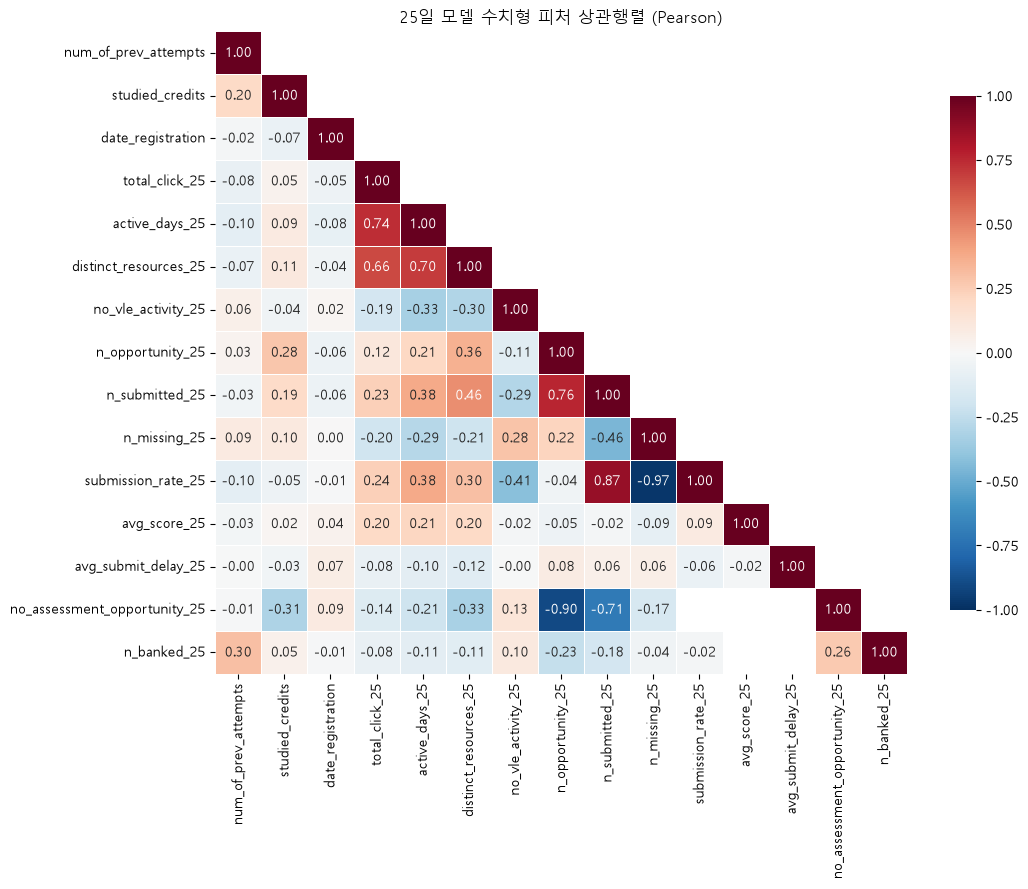

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=.5, cbar_kws={'shrink': .8}, ax=ax,
)
ax.set_title('25일 모델 수치형 피처 상관행렬 (Pearson)')
plt.tight_layout()
plt.show()

In [6]:
# |r| >= 0.6 인 쌍만 추출해 문제 후보를 좁힌다
pairs = (
    corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    .stack()
    .rename('r')
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b'})
)
high_corr = pairs.loc[pairs['r'].abs() >= 0.6].sort_values('r', key=abs, ascending=False)
high_corr.round(3)

,feature_a,feature_b,r
145,n_missing_25,submission_rate_25,-0.970
118,n_opportunity_25,no_assessment_opportunity_25,-0.902
130,n_submitted_25,submission_rate_25,0.872
113,n_opportunity_25,n_submitted_25,0.765
49,total_click_25,active_days_25,0.739
133,n_submitted_25,no_assessment_opportunity_25,-0.709
65,active_days_25,distinct_resources_25,0.699
50,total_click_25,distinct_resources_25,0.663


**해석**

`|r| >= 0.6`인 쌍은 두 덩어리로 나뉜다.

1. **평가 행동 덩어리** — `n_missing_25` ↔ `submission_rate_25`(-0.97),
   `no_assessment_opportunity_25` ↔ `n_opportunity_25`(-0.90),
   `submission_rate_25` ↔ `n_submitted_25`(0.87), `n_opportunity_25` ↔ `n_submitted_25`(0.77).
   상관이 0.9를 넘는 것은 단순한 "비슷한 변수"가 아니라 **정의상 서로를 계산할 수 있는 관계**
   임을 시사한다. 4절에서 항등식으로 확인한다.
2. **VLE 활동량 덩어리** — `active_days_25` ↔ `distinct_resources_25`(0.70),
   `total_click_25` ↔ `active_days_25`(0.74), `total_click_25` ↔ `distinct_resources_25`(0.66).
   "많이 클릭한 학생이 여러 날 접속하고 여러 자원을 본다"는 자연스러운 동행이지만 항등식은
   아니다. 5절 VIF로 심각도를 판단한다.

새로 추가된 `n_banked_25`는 어느 피처와도 |r| 0.6 미만이다. 가장 높은 상관은 `num_of_prev_attempts`와 0.30이다
(이월은 재수강생에게만 생기므로 자연스러운 관계). 4.5절에서 따로 검증한다.

## 4. 수학적 종속성 정리

상관계수는 "비슷하다"까지만 말해준다. 여기서는 **정의상 완전히 결정되는 관계(항등식)**를
데이터로 검증해 어떤 컬럼이 정보를 하나도 추가하지 않는지 확정한다.

### 4.1 평가 행동 5종의 항등식 검증

통합 테이블 생성 규칙(`02_Integrated_Table.ipynb`)상 기대되는 관계는 다음 세 개다.

1. `n_submitted_25 + n_missing_25 = n_opportunity_25` — 기회는 제출 아니면 미제출
2. `submission_rate_25 = n_submitted_25 / n_opportunity_25` (단, `n_opportunity_25 > 0`)
3. `no_assessment_opportunity_25 = 1{n_opportunity_25 == 0}`

세 항등식이 모두 성립하면 5개 컬럼의 **자유도는 2개**다.

In [7]:
identity_checks = {}

# 항등식 1
identity_checks['n_submitted + n_missing = n_opportunity 위반'] = int(
    (model_df_clean['n_submitted_25'] + model_df_clean['n_missing_25']
     != model_df_clean['n_opportunity_25']).sum()
)

# 항등식 2 (기회가 있는 행만 대상, 부동소수 비교는 np.isclose)
has_opp = model_df_clean['n_opportunity_25'] > 0
identity_checks['submission_rate = n_submitted / n_opportunity 위반'] = int(
    (~np.isclose(
        model_df_clean.loc[has_opp, 'submission_rate_25'],
        model_df_clean.loc[has_opp, 'n_submitted_25'] / model_df_clean.loc[has_opp, 'n_opportunity_25'],
    )).sum()
)

# 항등식 3
identity_checks['no_assessment_opportunity = 1{n_opportunity == 0} 위반'] = int(
    (model_df_clean['no_assessment_opportunity_25']
     != (model_df_clean['n_opportunity_25'] == 0).astype(float)).sum()
)

# 참고: submission_rate 결측이 정확히 기회 없음과 일치하는지
identity_checks['submission_rate 결측 != 기회 없음 위반'] = int(
    (model_df_clean['submission_rate_25'].isna() != ~has_opp).sum()
)

identity_result = pd.Series(identity_checks, name='위반 건수')
print(identity_result)
assert (identity_result == 0).all(), '기대한 항등식이 깨진 행이 있음'
print()
print('n_opportunity_25 분포:')
print(model_df_clean['n_opportunity_25'].value_counts().sort_index())

n_submitted + n_missing = n_opportunity 위반              0
submission_rate = n_submitted / n_opportunity 위반        0
no_assessment_opportunity = 1{n_opportunity == 0} 위반    0
submission_rate 결측 != 기회 없음 위반                          0
Name: 위반 건수, dtype: int64

n_opportunity_25 분포:
n_opportunity_25
0.0     5452
1.0    21036
2.0     1166
Name: count, dtype: int64


**해석**

네 항목 모두 위반 0건이다. 즉 `n_opportunity_25`와 `n_submitted_25` 두 값만 알면
`n_missing_25`, `submission_rate_25`, `no_assessment_opportunity_25`는 **계산으로 전부 복원된다.**
세 컬럼은 정보를 0비트도 추가하지 않는다.

`n_opportunity_25`가 {0, 1, 2}의 세 값만 갖는다는 점도 확인된다(0: 5,452 / 1: 21,036 / 2: 1,166행).
25일까지 마감되는 TMA/CMA(가중치 무관)가 과목 일정상 최대 2개(DDD 2013B)이고, 여기서 이월 평가를 빼기 때문이다.
정의 변경 후 `n_opportunity_25`는 학생마다 다를 수 있지만(이월), 항등식은 그대로 성립한다.

### 4.2 VLE 파생 플래그의 항등식 검증

`no_vle_activity_25`도 `total_click_25`에서 파생된 플래그로 보인다.

In [8]:
vle_identity = int(
    (model_df_clean['no_vle_activity_25']
     != (model_df_clean['total_click_25'] == 0).astype(float)).sum()
)
print('no_vle_activity = 1{total_click == 0} 위반:', vle_identity)
assert vle_identity == 0, 'no_vle_activity 항등식 위반'

print('무활동 학생 수:', int(model_df_clean['no_vle_activity_25'].sum()))
print()
print('무활동 여부별 이탈률:')
print(
    model_df_clean.groupby('no_vle_activity_25')[TARGET]
    .agg(['size', 'mean']).round(3)
)

no_vle_activity = 1{total_click == 0} 위반: 0
무활동 학생 수: 1302

무활동 여부별 이탈률:
                     size   mean
no_vle_activity_25              
0.0                 26352  0.186
1.0                  1302  0.261


**해석**

`no_vle_activity_25` 역시 `total_click_25 == 0`과 완전히 일치한다. 정보량 측면에서는
중복이지만 4.4절에서 보듯 **이 플래그는 유지하고 `no_assessment_opportunity_25`는 제거**하는,
대칭적으로 보이지만 서로 다른 판단을 한다. 근거는 4.4절에 정리한다.

25일까지 클릭이 전혀 없는 1,302명의 이탈률은 전체 평균(19.0%)보다 뚜렷하게 높다.
"활동량 0"은 단순한 최솟값이 아니라 별도의 위험 상태다.

### 4.3 종속 컬럼을 모두 넣은 VIF — 완전 다중공선성 확인

항등식 1은 **선형** 항등식이므로, `n_opportunity_25`/`n_submitted_25`/`n_missing_25`를
동시에 회귀에 넣으면 설계행렬이 특이(singular)해진다. VIF가 무한대로 발산하는지 확인한다.

In [9]:
def compute_vif(X: pd.DataFrame) -> pd.Series:
    """상수항을 추가해 VIF를 계산하고 상수항은 결과에서 제외한다."""
    Xc = add_constant(X.astype(float), has_constant='add')
    vifs = {col: variance_inflation_factor(Xc.values, i) for i, col in enumerate(Xc.columns)}
    return pd.Series(vifs).drop('const').sort_values(ascending=False)


# 구조적 결측이 없는 수치형 후보 전체 (avg_score/avg_submit_delay/submission_rate 제외)
vif_all_cols = [
    'num_of_prev_attempts', 'studied_credits', 'date_registration',
    'total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25',
    'n_opportunity_25', 'n_submitted_25', 'n_missing_25', 'no_assessment_opportunity_25', 'n_banked_25',
]
vif_all = compute_vif(model_df_clean[vif_all_cols])
vif_all.round(2)

C:\DA_WorkSpace\Personal_OULAD_Churn_Prediction\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


n_submitted_25                   inf
n_missing_25                     inf
n_opportunity_25                 inf
no_assessment_opportunity_25    5.71
active_days_25                  2.90
total_click_25                  2.56
distinct_resources_25           2.52
no_vle_activity_25              1.22
n_banked_25                     1.21
studied_credits                 1.17
num_of_prev_attempts            1.16
date_registration               1.02
dtype: float64

**해석**

`n_opportunity_25`, `n_submitted_25`, `n_missing_25`의 VIF가 **`inf`**로 발산한다.
이는 "상관이 좀 높다" 수준이 아니라 세 변수가 정확히 하나의 선형식으로 묶여 있다는
수학적 증거다. 이 상태로 Logistic Regression을 적합하면 계수가 유일하게 결정되지 않고
해석이 불가능해진다(sklearn은 정규화 덕에 에러 없이 통과하지만, 계수는 임의로 배분된다).

`no_assessment_opportunity_25`의 VIF는 5.71이다. `1{n_opportunity == 0}`은 `n_opportunity`의
선형함수가 아니라서 `inf`까지 가지 않지만, 여전히 높다.

새 피처 `n_banked_25`의 VIF는 1.21로, 종속 컬럼을 모두 넣은 상태에서도 다른 피처와 거의 겹치지 않는다.

### 4.4 남길 2개 선택 — 세 대안 비교

자유도가 2개이므로 5개 중 2개만 남긴다. `n_opportunity_25`는 "그 학생에게 25일까지
평가 기회가 몇 번 있었는가"라는 **분모**이자 모듈·학기 일정에서 오는 외생 변수라 어떤
대안에서도 유지한다. 나머지 한 칸을 무엇으로 채울지가 실제 선택지다.

| 대안 | 두 번째 피처 | 구조적 결측 | 해석 | 비고 |
|---|---|---|---|---|
| **A (채택)** | `n_submitted_25` | **없음** | "25일까지 실제로 몇 개 냈는가" | 대치 불필요 |
| B | `submission_rate_25` | 5,452행 | "기회 대비 제출률" | 기회 없음을 대치해야 함 |
| C | `n_missing_25` | 없음 | "몇 개 놓쳤는가" | 대치 불필요 |

세 대안은 **정보량이 수학적으로 동일**하다(A가 주어지면 B·C를 계산할 수 있고 역도 성립).
따라서 성능 차이가 나면 안 되고, 선택 기준은 성능이 아니라 **결측 처리 부담과 해석 명확성**
이어야 한다. 실제로 동일 조건에서 성능이 같은지 아래에서 확인한다.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# 학기 파생(7절에서 확정할 형태를 미리 사용)
model_df_clean['presentation_period'] = model_df_clean['code_presentation'].str[-1]

y = model_df_clean[TARGET].astype(int)
groups = model_df_clean['id_student']

# 검증 조건은 세 대안에서 완전히 동일하게 고정한다
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

shared_num = [
    'num_of_prev_attempts', 'studied_credits', 'date_registration',
    'total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25',
    'avg_score_25', 'avg_submit_delay_25', 'n_banked_25',
]
shared_cat = [
    'gender', 'region', 'highest_education', 'imd_band', 'age_band',
    'disability', 'code_module', 'presentation_period',
]

alternatives = {
    'A: n_opportunity + n_submitted': ['n_opportunity_25', 'n_submitted_25'],
    'B: n_opportunity + submission_rate': ['n_opportunity_25', 'submission_rate_25'],
    'C: n_opportunity + n_missing': ['n_opportunity_25', 'n_missing_25'],
}

rows = []
for name, extra_num in alternatives.items():
    num_cols = shared_num + extra_num
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median', add_indicator=True)),
            ('scale', RobustScaler()),
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), shared_cat),
    ])
    pipe = Pipeline([
        ('pre', pre),
        ('clf', LogisticRegression(max_iter=3000, class_weight='balanced')),
    ])
    scores = cross_val_score(
        pipe, model_df_clean[num_cols + shared_cat], y,
        groups=groups, cv=cv, scoring='average_precision', n_jobs=-1,
    )
    rows.append({
        '대안': name,
        'PR-AUC 평균': scores.mean(),
        'PR-AUC 표준편차': scores.std(),
        '대치 필요 컬럼 수': int(model_df_clean[extra_num].isna().any().sum()),
    })

alt_compare = pd.DataFrame(rows).round(4)
alt_compare

,대안,PR-AUC 평균,PR-AUC 표준편차,대치 필요 컬럼 수
0,A: n_opportunity + n_submitted,0.3858,0.0116,0
1,B: n_opportunity + submission_rate,0.3850,0.0109,1
2,C: n_opportunity + n_missing,0.3858,0.0115,0


**정의 변경 영향 분해와 플래그 VIF — 재현 코드**

아래 해석에서 쓰는 수치를 계산한다. 대안 A와 같은 파이프라인·분할로 OOF 예측을 만든 뒤, 정의 변경으로 값이 바뀐 행(BBB 2014J, 이월 보유 행)과 나머지 행의 PR-AUC를 따로 보고, 모델링 개발 세트(2013B·2013J·2014B)로도 같은 비교를 한다. `no_assessment_opportunity_25` 플래그를 축소 피처셋에 넣었을 때의 VIF와 BBB 2014J 평가 점수 성격도 함께 확인한다.

In [11]:
from sklearn.metrics import average_precision_score
from sklearn.model_selection import cross_val_predict


def logistic_pipe(num_cols):
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median', add_indicator=True)),
            ('scale', RobustScaler()),
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), shared_cat),
    ])
    return Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced'))])


def definition_change_rows(data, label):
    """전체 CV와, 정의 변경으로 값이 바뀐 행/나머지 행의 OOF PR-AUC."""
    y_d = data[TARGET].astype(int).to_numpy()
    groups_d = data['id_student']
    is_bbb14j = ((data['code_module'] == 'BBB') & (data['code_presentation'] == '2014J')).to_numpy()
    is_banked = (data['n_banked_25'] > 0).to_numpy()
    rest = ~(is_bbb14j | is_banked)
    rows = []
    for name, num_cols in {
        '변경 후': [c for c in shared_num if c != 'n_banked_25'] + alternatives['A: n_opportunity + n_submitted'],
        '변경 후 + n_banked_25': shared_num + alternatives['A: n_opportunity + n_submitted'],
    }.items():
        X_d = data[num_cols + shared_cat]
        cv_mean = cross_val_score(logistic_pipe(num_cols), X_d, y_d, groups=groups_d, cv=cv,
                                  scoring='average_precision', n_jobs=4).mean()
        oof = cross_val_predict(logistic_pipe(num_cols), X_d, y_d, groups=groups_d, cv=cv,
                                method='predict_proba', n_jobs=4)[:, 1]
        subset_ap = lambda m: average_precision_score(y_d[m], oof[m]) if m.any() else np.nan
        rows.append({'대상': label, '구성': name, 'CV PR-AUC': cv_mean,
                     'BBB 2014J 행': subset_ap(is_bbb14j), '이월 보유 행': subset_ap(is_banked), '나머지 행': subset_ap(rest)})
    return rows


dev_df = model_df_clean[model_df_clean['code_presentation'] != '2014J'].reset_index(drop=True)
decomp = pd.DataFrame(definition_change_rows(model_df_clean, '4개 학기 전체') +
                      definition_change_rows(dev_df, '개발 세트')).round(4)
print(decomp.to_string(index=False))

# 기회 0 플래그를 축소 피처셋에 넣었을 때의 VIF
flag_cols = [
    'num_of_prev_attempts', 'studied_credits', 'date_registration',
    'total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25',
    'n_opportunity_25', 'n_submitted_25', 'n_banked_25', 'no_assessment_opportunity_25',
]
vif_flag = compute_vif(model_df_clean[flag_cols])
print()
print('축소 피처셋 + no_assessment_opportunity_25 VIF 상위:')
print(vif_flag.round(2).head(3).to_string())

# BBB 2014J 평가 점수·미제출 신호의 성격
bbb = model_df_clean[(model_df_clean['code_module'] == 'BBB') & (model_df_clean['n_opportunity_25'] > 0)]
bbb_term = np.where(bbb['code_presentation'] == '2014J', 'BBB 2014J', '다른 BBB 학기')
not_submitted = bbb['n_submitted_25'] == 0
print()
print(pd.DataFrame({
    '평균 점수': bbb.groupby(bbb_term)['avg_score_25'].mean(),
    '미제출 이탈률': bbb[not_submitted].groupby(bbb_term[not_submitted.to_numpy()])[TARGET].mean(),
}).round(3).to_string())

      대상                 구성  CV PR-AUC  BBB 2014J 행  이월 보유 행  나머지 행
4개 학기 전체               변경 후     0.3856       0.2088   0.2969 0.3957
4개 학기 전체 변경 후 + n_banked_25     0.3858       0.2089   0.2995 0.3955
   개발 세트               변경 후     0.3989          NaN   0.3084 0.3990
   개발 세트 변경 후 + n_banked_25     0.3994          NaN   0.3180 0.3990



축소 피처셋 + no_assessment_opportunity_25 VIF 상위:
n_opportunity_25                6.86
no_assessment_opportunity_25    5.71
n_submitted_25                  2.97

            평균 점수  미제출 이탈률
BBB 2014J  59.159    0.263
다른 BBB 학기  71.821    0.351


**해석**

세 대안의 PR-AUC가 사실상 동일하다(A 0.3858 / B 0.3850 / C 0.3858). 예측한 대로 **정보량이
같으므로 성능으로는 구분되지 않는다.** 따라서 선택 기준은 다음 두 가지다.

1. **결측 처리 부담**: B는 `submission_rate_25`가 5,452행(19.7%) 구조적 결측이라
   Logistic/RandomForest에서 대치가 필요하다. 그런데 이 결측은
   `0912_01_missing_value_policy.md` 3.1절에서 확인한 "평가 기회 자체가 없었음"이고,
   중앙값으로 채우면 *기회가 없던 학생이 평균만큼 제출한 것처럼* 보인다. A·C는 결측이
   0건이라 이 위험이 아예 발생하지 않는다.
2. **해석 방향**: A(`n_submitted_25`)는 "낸 개수가 많을수록 잔류", C(`n_missing_25`)는
   "놓친 개수가 많을수록 이탈"로 부호만 반대이며 정보는 같다. 개입 설계에서 "제출을
   유도한다"가 행동안이므로 **제출 쪽을 주 피처로 두는 A**가 서술과 자연스럽게 맞는다.

→ **대안 A(`n_opportunity_25` + `n_submitted_25`)를 채택한다.**

부수 효과로, 원래 모델별로 분기해야 했던 구조적 결측 3종 중 `submission_rate_25`가 피처셋에서
빠지므로 **NaN을 안고 가는 피처가 `avg_score_25`·`avg_submit_delay_25` 2개로 줄어든다.**
`0912_01_missing_value_policy.md` 5절의 모델별 분기 전략은 이 두 컬럼에만 적용된다.

**`no_assessment_opportunity_25`는 제외하되 `no_vle_activity_25`는 유지하는 이유**

두 컬럼 모두 다른 컬럼에서 파생된 0/1 플래그지만 상황이 다르다.

- `no_assessment_opportunity_25 = 1{n_opportunity_25 == 0}`인데 `n_opportunity_25`는
  값이 {0, 1, 2} 세 개뿐이다. 원-핫/트리 어느 쪽으로 인코딩해도 "기회 0" 상태는 이미
  완전히 표현된다. 플래그는 순수 중복이고, 축소 피처셋에 넣으면 `n_opportunity_25`의 VIF만 2.82 → 6.86으로 올린다(플래그 자체 5.71, 위 재현 코드).
- `no_vle_activity_25 = 1{total_click_25 == 0}`의 경우 `total_click_25`는 0~5,818의
  연속형이다. 선형 모델은 `total_click_25`의 계수 하나로 "0과 1의 차이"와
  "3,000과 3,001의 차이"를 같게 취급하므로, **"활동이 아예 없음"이라는 불연속 상태를
  표현할 수 없다.** 이 플래그는 중복이 아니라 선형 모델이 놓치는 꺾임을 보완한다.
  VIF도 1.21로 낮다.

**정의 변경 전후 수치 차이에 대한 주의 (2026-09-13)**

정의 변경 전 이 비교의 대안 A는 0.3903이었고 지금은 0.3858이다(−0.0045, 표준편차 0.012 안쪽). 원인을 따로 분해했다.

| 비교 | 변경 전 (개정 당시 기록) | 변경 후 | 변경 후 + `n_banked_25` |
|---|---:|---:|---:|
| 이 절의 CV (4개 학기 전체) | 0.3903 | 0.3856 | 0.3858 |
| └ 값이 바뀐 BBB 2014J 행만 | 0.1840 | 0.2088 | 0.2089 |
| └ 값이 바뀐 이월 행만 | 0.2858 | 0.2969 | 0.2995 |
| └ 값이 그대로인 나머지 행 | 0.4020 | 0.3957 | 0.3955 |
| **모델링 개발 세트 CV (2013B·2013J·2014B)** | **0.3962** | **0.3989** | **0.3994** |

"변경 후" 두 열은 위 재현 코드 출력이다. "변경 전" 열은 정의 변경 당시(2026-09-13) 변경 전 통합 정본으로 계산한 기록이며, 변경 전 파일을 보관하지 않아 이 노트북에서는 다시 계산하지 않는다.

- **바뀐 행 자체의 순위는 좋아졌다.** 오히려 값이 그대로인 나머지 행이 떨어졌다.
- BBB 2014J의 19일 TMA는 가중치 0이라 **점수 성격이 다르다.** 평균 점수는 59.2점으로 다른 BBB 학기(71.8점)보다 낮고,
  미제출 이탈률도 26.3%로 다른 BBB 학기(35.1%)보다 약하다. 4개 학기를 섞은 CV에서는 이 점수가 공통 계수(`avg_score_25`,
  `n_submitted_25`)를 흐려 다른 행의 성능을 낮춘다.
- **실제 모델링은 2014J를 학습에 쓰지 않는다.** 개발 3개 학기 CV에서는 새 정의가 0.3962 → 0.3994로 오히려 좋다.
  따라서 정의 변경을 유지한다.
- 대신 **모델링 holdout(2014J)의 BBB 결과를 해석할 때 "가중치 0 평가의 점수·제출"이라는 차이를 반드시 함께 본다.**
  `03_Modeling`의 과목별 성능 보고에 명시한다.

### 4.5 이월 플래그 `n_banked_25` — 추가 피처 검증

2026-09-13 평가 기회 정의 변경(`0913_01_assessment_opportunity_banked.md`)으로 **이월 평가를 학생별 기회에서 빼고,
이월 개수를 `n_banked_25`로 따로 남겼다.** 평가 기회 정의 변경(`0913_01`)에서 "기회에서 제외 + 플래그"로 정했으므로 최종 피처에 넣되,
넣기 전에 다음 세 가지를 확인한다.

1. **종속성**: `n_banked_25`가 다른 피처로 완전히 복원되는지. 복원되면 정보를 추가하지 않는다.
   가장 가까운 후보는 `num_of_prev_attempts`(이월은 재수강생에게만 생김)와 `n_opportunity_25`다.
2. **필요성**: 이 플래그가 없으면 "이월로 기회 0"인 재수강생과 "과목 일정상 기회 0"(EEE·GGG) 학생이 같은
   `n_opportunity_25 = 0`이 된다. 두 집단의 이탈률이 다르면(`03_Landmark25_EDA` 6절: 24.8% vs 10.8%) 구분할 가치가 있다.
3. **성능 영향**: 4.4절과 같은 CV로 넣었을 때와 뺐을 때를 비교한다. 성능 차이는 채택 조건이 아니라 확인용이다.

In [12]:
# 1) 종속성: 분포와 다른 피처와의 관계
banked = model_df_clean['n_banked_25']
print('n_banked_25 분포:', banked.value_counts().sort_index().to_dict())
print('이월 있는 학생의 재수강 이력 분포:', model_df_clean.loc[banked > 0, 'num_of_prev_attempts'].value_counts().sort_index().to_dict())
print('재수강생 중 이월 있는 비율:', round((banked[model_df_clean['num_of_prev_attempts'] > 0] > 0).mean(), 3))
print('상관 — num_of_prev_attempts:', round(banked.corr(model_df_clean['num_of_prev_attempts']), 3),
      '/ n_opportunity_25:', round(banked.corr(model_df_clean['n_opportunity_25']), 3))

# 이월 여부가 재수강 이력으로 결정되지 않음을 확인 (재수강생 대부분은 이월이 없다)
assert ((banked > 0) <= (model_df_clean['num_of_prev_attempts'] > 0)).all(), '이월 있는데 재수강 이력 없음'
assert (banked[model_df_clean['num_of_prev_attempts'] > 0] == 0).any(), '재수강생 전원이 이월 — 완전 종속'

# 2) 필요성: 기회 0의 두 원인별 이탈률
opp0 = model_df_clean[model_df_clean['n_opportunity_25'] == 0]
opp0_reason = np.where(opp0['n_banked_25'] > 0, '이월로 기회 0', '과목 일정상 기회 0')
print()
print(opp0.groupby(opp0_reason)[TARGET].agg(['size', 'mean']).round(3))

# 3) 성능 영향 (4.4절 대안 A와 같은 조건)
banked_rows = []
for name, num_cols in {
    '대안 A + n_banked_25 (채택)': shared_num + ['n_opportunity_25', 'n_submitted_25'],
    '대안 A − n_banked_25': [c for c in shared_num if c != 'n_banked_25'] + ['n_opportunity_25', 'n_submitted_25'],
}.items():
    pre = ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median', add_indicator=True)),
            ('scale', RobustScaler()),
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), shared_cat),
    ])
    pipe = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=3000, class_weight='balanced'))])
    scores = cross_val_score(pipe, model_df_clean[num_cols + shared_cat], y, groups=groups, cv=cv,
                             scoring='average_precision', n_jobs=-1)
    banked_rows.append({'구성': name, 'PR-AUC 평균': scores.mean(), 'PR-AUC 표준편차': scores.std()})
pd.DataFrame(banked_rows).round(4)

n_banked_25 분포: {0.0: 27190, 1.0: 452, 2.0: 12}
이월 있는 학생의 재수강 이력 분포: {1: 369, 2: 79, 3: 12, 4: 3, 6: 1}
재수강생 중 이월 있는 비율: 0.133
상관 — num_of_prev_attempts: 0.299 / n_opportunity_25: -0.234

             size   mean
과목 일정상 기회 0  4989  0.107
이월로 기회 0      463  0.248


,구성,PR-AUC 평균,PR-AUC 표준편차
0,대안 A + n_banked_25 (채택),0.3858,0.0116
1,대안 A − n_banked_25,0.3856,0.0124


**해석**

1. **완전 종속이 아니다.** 이월 보유 학생 464명(1개 452명, 2개 12명)은 모두 재수강생이지만, **재수강생 중 이월이 있는 비율은 13.3%뿐**이다.
   `num_of_prev_attempts`와의 상관은 0.30, `n_opportunity_25`와는 −0.23이다. 다른 피처로 복원되지 않는다.
2. **구분할 가치가 있다.** 기회 0인 학생 중 "과목 일정상 기회 0"(4,989명)의 이탈률은 10.7%, "이월로 기회 0"(463명)은 24.8%다.
   이 플래그가 없으면 두 집단이 같은 `n_opportunity_25 = 0`이 된다. `code_module`이 일부를 가르지만, 같은 과목 안의 재수강생은 구분하지 못한다.
3. **성능 영향은 작다.** 이 CV에서 넣었을 때 0.3858, 뺐을 때 0.3856이다. 모델링 개발 세트 CV에서는 0.3989 → 0.3994다(4.4절 표).
   이월자가 전체의 1.7%라 전체 지표에서는 작게 보이지만, **이월 행 안의 순위는 0.3084 → 0.3180으로 나아진다**(개발 세트 기준, 4.4절 재현 코드).

→ 정의 변경 결정("기회에서 제외 + 플래그")대로 **`n_banked_25`를 최종 수치형 피처에 추가한다.** 5절 VIF에서 다중공선성을 다시 확인한다.

## 5. 축소 피처셋 VIF 재검증

대안 A를 적용해 종속 파생(`n_missing_25`, `submission_rate_25`,
`no_assessment_opportunity_25`)을 제거한 뒤 VIF를 다시 계산한다. 통상 기준은 VIF 5(엄격) 또는
10(완화)이다.

In [13]:
vif_reduced_cols = [
    'num_of_prev_attempts', 'studied_credits', 'date_registration',
    'total_click_25', 'active_days_25', 'distinct_resources_25', 'no_vle_activity_25',
    'n_opportunity_25', 'n_submitted_25', 'n_banked_25',
]
vif_reduced = compute_vif(model_df_clean[vif_reduced_cols])
print(vif_reduced.round(2))
print()
print('최대 VIF:', round(vif_reduced.max(), 2))
assert vif_reduced.max() < 5, 'VIF 5 기준을 넘는 피처가 남아 있음'

n_submitted_25           2.95
active_days_25           2.90
n_opportunity_25         2.82
total_click_25           2.54
distinct_resources_25    2.51
no_vle_activity_25       1.21
n_banked_25              1.19
num_of_prev_attempts     1.16
studied_credits          1.14
date_registration        1.01
dtype: float64

최대 VIF: 2.95


In [14]:
# 구조적 결측이 있는 avg_score_25 / avg_submit_delay_25 포함 VIF
# (결측 행을 제외해야 OLS가 적합되므로 '제출 이력이 있는 행'만 대상으로 별도 확인)
submitted_rows = model_df_clean.loc[model_df_clean['n_submitted_25'] > 0]
vif_with_score_cols = vif_reduced_cols + ['avg_score_25', 'avg_submit_delay_25']
subset = submitted_rows[vif_with_score_cols].dropna()
constant_cols = [c for c in vif_with_score_cols if subset[c].nunique() <= 1]  # 이 부분집합에서 n_banked_25는 전부 0
print('부분집합에서 상수라 제외한 컬럼:', constant_cols)
vif_with_score = compute_vif(subset.drop(columns=constant_cols))

print(f'대상 행 수: {len(submitted_rows[vif_with_score_cols].dropna()):,}행 (제출 이력 있는 행)')
print()
print(vif_with_score.round(2))

부분집합에서 상수라 제외한 컬럼: ['n_banked_25']


대상 행 수: 19,299행 (제출 이력 있는 행)

n_opportunity_25         6.27
n_submitted_25           6.23
active_days_25           2.35
total_click_25           2.32
distinct_resources_25    2.06
avg_score_25             1.07
num_of_prev_attempts     1.04
avg_submit_delay_25      1.04
studied_credits          1.03
no_vle_activity_25       1.02
date_registration        1.02
dtype: float64


**해석**

- 축소 피처셋(`n_banked_25` 포함 10개)의 최대 VIF는 `n_submitted_25`의 **2.95**다. `inf`에서 2.95로 내려왔고 엄격 기준인 5도 넘지 않는다.
  남은 다중공선성은 Logistic 계수 해석을 방해할 수준이 아니다. `n_banked_25`의 VIF는 1.19다.
- 3절에서 걱정했던 VLE 3종(`total_click_25` 2.54, `active_days_25` 2.90, `distinct_resources_25` 2.51)도 전부 3 미만이다.
  상관이 0.66~0.74여도 셋이 서로를 결정하지는 않으며, 각각 다른 행동을 잡는다(총량 / 꾸준함 / 학습자료 범위). **세 개 모두 유지한다.**
- 점수·지연을 포함한 경우(제출 이력 있는 19,299행)에는 최대 VIF가 6.3 수준이다. 제출 이력 있는 행에서는
  `n_opportunity_25`·`n_submitted_25`가 더 강하게 묶이기 때문이다. 이 표는 전체 행이 아닌 부분집합 기준이라 참고값으로만 본다.
  실제 모델은 전체 27,654행을 쓰므로 위쪽 표가 기준이다.
  이 부분집합에서는 `n_banked_25`가 전부 0이라(이월 평가는 제출 기록이 없음) VIF 계산에서 뺐다.

## 6. 범주형 피처 간 연관성

범주형끼리는 VIF를 직접 쓸 수 없으므로 Cramér's V(0~1)로 연관 강도를 본다.
`04_next_steps.md` P3의 "`gender`와 `code_module`의 구조적 관계를 해석에 반영" 항목에
해당한다.

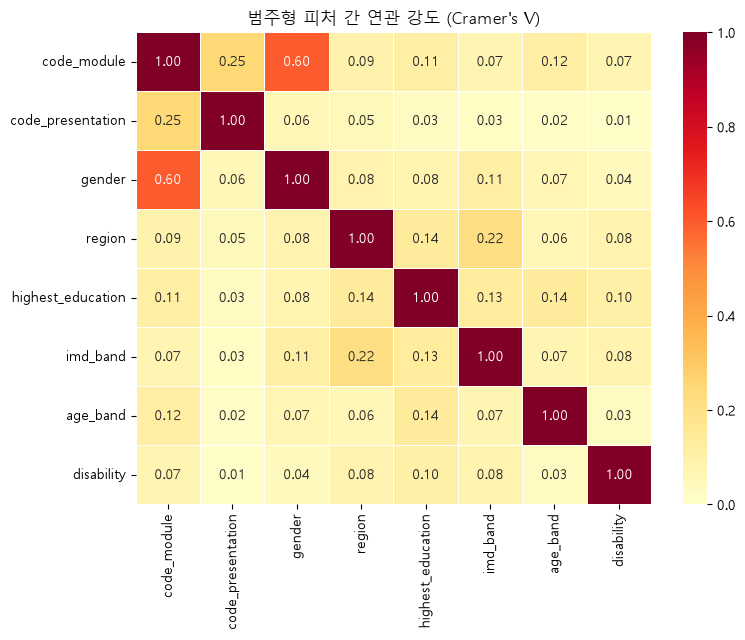

,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability
code_module,1.000,0.253,0.601,0.093,0.113,0.071,0.121,0.074
code_presentation,0.253,1.000,0.062,0.049,0.034,0.025,0.023,0.008
gender,0.601,0.062,1.000,0.083,0.079,0.112,0.069,0.042
region,0.093,0.049,0.083,1.000,0.140,0.215,0.060,0.084
highest_education,0.113,0.034,0.079,0.140,1.000,0.133,0.138,0.103
imd_band,0.071,0.025,0.112,0.215,0.133,1.000,0.073,0.083
age_band,0.121,0.023,0.069,0.060,0.138,0.073,1.000,0.032
disability,0.074,0.008,0.042,0.084,0.103,0.083,0.032,1.000


In [15]:
def cramers_v(a: pd.Series, b: pd.Series) -> float:
    table = pd.crosstab(a, b)
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    return float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))


cat_for_assoc = cat_candidates  # 원본 code_presentation 포함 상태로 진단
assoc = pd.DataFrame(index=cat_for_assoc, columns=cat_for_assoc, dtype=float)
for a in cat_for_assoc:
    for b in cat_for_assoc:
        assoc.loc[a, b] = cramers_v(model_df_clean[a], model_df_clean[b])

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    assoc.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=1, linewidths=.5, ax=ax,
)
ax.set_title("범주형 피처 간 연관 강도 (Cramer's V)")
plt.tight_layout()
plt.show()

assoc.astype(float).round(3)

In [16]:
# gender × code_module 구조 확인
gender_by_module = pd.crosstab(
    model_df_clean['code_module'], model_df_clean['gender'], normalize='index'
).round(3)
gender_by_module['이탈률'] = (
    model_df_clean.groupby('code_module')[TARGET].mean().round(3)
)
gender_by_module['행 수'] = model_df_clean.groupby('code_module').size()
gender_by_module

gender,F,M,이탈률,행 수
code_module,,,,
AAA,0.408,0.592,0.135,718
BBB,0.883,0.117,0.150,6482
CCC,0.242,0.758,0.303,3526
DDD,0.396,0.604,0.245,5311
EEE,0.112,0.888,0.134,2553
FFF,0.180,0.820,0.192,6628
GGG,0.808,0.192,0.080,2436


**해석**

`gender` × `code_module`의 Cramér's V가 **0.601**로 유일하게 두드러진다. 교차표를 보면
모듈별 성비가 극단적으로 갈린다(일부 모듈은 한쪽 성별이 대다수). OULAD의 모듈이 STEM/
사회과학 등 서로 다른 분야여서 생기는 실제 구조다(분야 구분 출처: Kuzilek, Hlosta & Zdrahal, 2017,
*Scientific Data* 4:170171, Table 1 — AAA·BBB·GGG 사회과학, CCC·DDD·EEE·FFF STEM).

`03_Landmark25_EDA` 10절에서 이 구조가 **심슨의 역설**을 만든다는 것을 확인했다. 전체로는 남성 이탈률이 2.2%p 높지만,
과목 안에서는 7개 중 5개 과목에서 여성이 더 높고 가중 평균은 −2.2%p다. 두 피처를 모두 유지해야 하는 이유가 더 분명해졌다.

이는 **완전 공선성이 아니므로 피처를 제거할 이유는 없다.** 다만 해석 단계에서 다음을
반드시 명시한다.

> Logistic의 `gender` 계수는 "성별 자체의 효과"가 아니라 "모듈 구성으로 설명되지 않는
> 잔여 성별 효과"이며, `code_module` 계수와 서로 흡수 관계에 있다. 성별 효과를 단독으로
> 주장하려면 모듈별 층화 분석이나 permutation importance로 교차 확인해야 한다.

`code_module` × `code_presentation`의 V는 0.253이다. 모든 모듈이 모든 학기에 개설되지는
않기 때문인데, 이 역시 제거 사유는 아니다(7절에서 `code_presentation` 자체를 다르게 처리).
나머지 조합은 전부 0.25 미만으로 문제없다.

## 7. `code_presentation` → `presentation_period` 파생

`code_presentation`은 `2013B`/`2013J`/`2014B`/`2014J` 네 값이다(뒤 글자 B = 2월 개강,
J = 10월 개강). 이 컬럼을 원본 그대로 쓰면 문제가 생긴다.

**최종 평가를 마지막 학기(`2014J`) holdout으로 하기로 확정했으므로**, `code_presentation`을
원-핫 인코딩하면 holdout 학기에 해당하는 더미를 학습에서 한 번도 본 적이 없게 된다.
그 더미의 계수는 0(또는 정규화 기본값)이 되어 평가가 왜곡되고, 실제 배포 상황(새 학기 예측)도
재현하지 못한다.

대신 **개강 시기(B/J)만 파생**해서 쓴다. 새 학기에도 항상 관측 가능하고, 연도 정보는 빼서
시간 일반화를 확보한다.

In [17]:
# 학기별 / 개강시기별 이탈률 비교
by_presentation = (
    model_df_clean.groupby('code_presentation')[TARGET]
    .agg(['size', 'mean']).rename(columns={'size': '행 수', 'mean': '이탈률'}).round(3)
)
by_period = (
    model_df_clean.groupby('presentation_period')[TARGET]
    .agg(['size', 'mean']).rename(columns={'size': '행 수', 'mean': '이탈률'}).round(3)
)
print('code_presentation 별:')
print(by_presentation)
print()
print('presentation_period 별 (B=2월 개강, J=10월 개강):')
print(by_period)

# 파생 검증
assert set(model_df_clean['presentation_period'].unique()) == {'B', 'J'}, '파생 값 이상'
assert model_df_clean['presentation_period'].isna().sum() == 0, '파생 결측 발생'

code_presentation 별:
                    행 수    이탈률
code_presentation             
2013B              4274  0.221
2013J              7692  0.160
2014B              6538  0.207
2014J              9150  0.188

presentation_period 별 (B=2월 개강, J=10월 개강):
                       행 수    이탈률
presentation_period              
B                    10812  0.213
J                    16842  0.175


**해석**

학기별 이탈률은 2013B 22.1% → 2013J 16.0% → 2014B 20.7% → 2014J 18.8%로 움직이는데,
여기서 **연도가 아니라 개강 시기가 일관된 방향**을 만든다. B(2월 개강) 21.3% vs
J(10월 개강) 17.5%로 약 3.8%p 차이가 나고, 2013·2014 두 해 모두 B > J다.

따라서 `presentation_period`만 남겨도 학기 효과의 재현 가능한 부분은 보존된다. 반대로
연도 차이(2013 → 2014)는 다음 학기 예측에 그대로 적용할 근거가 없어, 학습해선 안 되는
정보에 가깝다.

`code_presentation` 원본은 **입력 피처에서 제외하되 학기 holdout 분할 키로는 사용**한다.
분할 키와 입력 피처는 다른 역할이다.

## 8. 최종 피처 목록 확정

In [18]:
FINAL_NUM_FEATURES = [
    # 학생 배경 (개강 전 확정)
    'num_of_prev_attempts',
    'studied_credits',
    'date_registration',
    # VLE 활동 (25일 관측창)
    'total_click_25',
    'active_days_25',
    'distinct_resources_25',
    'no_vle_activity_25',
    # 평가 행동 (25일 관측창) — 대안 A
    'n_opportunity_25',
    'n_submitted_25',
    'avg_score_25',          # 구조적 결측 유지
    'avg_submit_delay_25',   # 구조적 결측 유지
    'n_banked_25',           # 이월 평가 수 (0913_01 정의 변경, 4.5절)
]

FINAL_CAT_FEATURES = [
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'disability',
    'code_module',
    'presentation_period',   # code_presentation 대체 파생
]

FINAL_FEATURES = FINAL_NUM_FEATURES + FINAL_CAT_FEATURES

# 모델링 단계에서 쓸 보조 컬럼(피처가 아님)
GROUP_COL = 'id_student'           # StratifiedGroupKFold groups
HOLDOUT_KEY = 'code_presentation'  # 학기 holdout 분할 키

# NaN을 안고 가는 피처 (모델별 분기 대상)
NAN_FEATURES = ['avg_score_25', 'avg_submit_delay_25']

assert len(FINAL_FEATURES) == 20
print(f'최종 피처 {len(FINAL_FEATURES)}개 = 수치형 {len(FINAL_NUM_FEATURES)} + 범주형 {len(FINAL_CAT_FEATURES)}')
print()
print('결측 현황:')
print(model_df_clean[FINAL_FEATURES].isna().sum().loc[lambda s: s > 0])

최종 피처 20개 = 수치형 12 + 범주형 8

결측 현황:
avg_score_25           8355
avg_submit_delay_25    8348
dtype: int64


In [19]:
# 최종 피처 목록 검증
assert all(c in model_df_clean.columns for c in FINAL_FEATURES), '존재하지 않는 피처 포함'

# (1) 누수·상수·식별자 컬럼 미포함
forbidden = set(LEAK_COLS) | set(CONST_COLS) | set(ID_COLS) | {'code_presentation'}
assert not (set(FINAL_FEATURES) & forbidden), f'금지 컬럼 포함: {set(FINAL_FEATURES) & forbidden}'

# (2) 항등식으로 복원 가능한 종속 파생 미포함
dependent = {'n_missing_25', 'submission_rate_25', 'no_assessment_opportunity_25'}
assert not (set(FINAL_FEATURES) & dependent), '종속 파생 피처가 남아 있음'

# (3) 수치형 VIF 5 미만 (구조적 결측 2종 제외 — 5절과 동일 기준)
vif_final = compute_vif(model_df_clean[[c for c in FINAL_NUM_FEATURES if c not in NAN_FEATURES]])
assert vif_final.max() < 5, f'VIF 5 초과: {vif_final.max():.2f}'

# (4) 결측을 안고 가는 피처가 NAN_FEATURES 2개뿐임
nan_in_final = set(
    model_df_clean[FINAL_FEATURES].columns[model_df_clean[FINAL_FEATURES].isna().any()]
)
assert nan_in_final == set(NAN_FEATURES), f'예상과 다른 결측 피처: {nan_in_final}'

print('최종 피처 검증 통과')
print(f'  누수·상수·식별자 미포함, 종속 파생 미포함, 최대 VIF {vif_final.max():.2f}')
print(f'  NaN 유지 피처: {NAN_FEATURES}')

최종 피처 검증 통과
  누수·상수·식별자 미포함, 종속 파생 미포함, 최대 VIF 2.95
  NaN 유지 피처: ['avg_score_25', 'avg_submit_delay_25']


최종 20개 = 수치형 12(학생 배경 3, VLE 4, 평가 5 — `n_banked_25` 포함) + 범주형 8.

### 8.1 제외 피처와 사유

| 제외 컬럼 | 사유 |
|---|---|
| `id_student` | 그레인 식별자. 단 `StratifiedGroupKFold`의 `groups`로 사용 |
| `landmark_day` | 상수(25) |
| `eligible_at_25` | 상수(1) — 모델 대상 필터링 결과 |
| `cohort_status_25` | 상수(`model_eligible`) — 동일 |
| `final_result` | **누수**. 타깃이 여기서 직접 파생됨 |
| `date_unregistration` | **누수**. 25일 이후 시점의 탈퇴일 |
| `target_churn_after_25` | 타깃 |
| `n_missing_25` | `n_opportunity_25 - n_submitted_25`로 완전 복원(항등식 1). VIF `inf` |
| `submission_rate_25` | `n_submitted_25 / n_opportunity_25`로 완전 복원(항등식 2). 추가로 5,452행 구조적 결측 대치 부담 |
| `no_assessment_opportunity_25` | `1{n_opportunity_25 == 0}`로 완전 복원(항등식 3). `n_opportunity_25`가 3개 값뿐이라 이미 표현됨. VIF 5.71 |
| `code_presentation` | 2014J 학기 holdout과 충돌(미지 더미). `presentation_period` 파생으로 대체. 단 **holdout 분할 키로는 사용** |

### 8.2 모델별 인코딩·스케일링 방침

`0912_01_missing_value_policy.md` 5절과 `0912_02_outlier_policy.md` 4절을 최종 피처 목록에
적용한 결과다.

| 처리 | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| 수치형 결측(`avg_score_25`, `avg_submit_delay_25`) | `SimpleImputer` + `add_indicator=True` | 동일 | **대치 안 함**(NaN 그대로) |
| 수치형 스케일링 | `RobustScaler` | 불필요 | 불필요 |
| 범주형 인코딩 | `OneHotEncoder(drop='first', handle_unknown='ignore')` | `OneHotEncoder(handle_unknown='ignore')` | `OneHotEncoder(handle_unknown='ignore')` |
| 불균형 대응 | `class_weight='balanced'` | `class_weight='balanced'` | `scale_pos_weight` |

- Logistic에서 `drop='first'`를 쓰는 이유는 원-핫 더미 합이 1이 되어 상수항과 완전
  공선이 되는 것(dummy variable trap)을 막기 위함이다. 트리 모델은 상수항이 없어 불필요하다.
- 대치는 반드시 `Pipeline`/`ColumnTransformer` 안에서 수행해 **각 fold의 학습 부분에서만
  `fit`**되게 한다(대치값을 통해 검증 데이터가 새는 것을 방지).
- `RobustScaler`를 쓰는 근거는 `0912_02_outlier_policy.md` 4절(극단값을 제거·캡핑하지 않고
  스케일링으로 완화)이다.

## 9. 최종 피처 목록 저장

모델링 노트북이 같은 목록을 다시 타이핑하지 않도록 JSON으로 남긴다.

In [20]:
import json

FEATURE_SPEC_PATH = PROJECT_ROOT / 'CSV_files' / '통합 버전' / 'feature_spec_n25.json'

feature_spec = {
    'created_from': '05_Collinearity_Recheck.ipynb',
    'source_data': 'CSV_files/통합 버전/model_df_clean_n25.csv',
    'n_rows': int(len(model_df_clean)),
    'n_positive': int(model_df_clean[TARGET].sum()),
    'target': TARGET,
    'group_col': GROUP_COL,
    'holdout_key': HOLDOUT_KEY,
    'numeric_features': FINAL_NUM_FEATURES,
    'categorical_features': FINAL_CAT_FEATURES,
    'nan_features': NAN_FEATURES,
    'derived_features': {
        'presentation_period': 'code_presentation.str[-1] (B=2월 개강, J=10월 개강)',
    },
    'definition_version': '0913_01 — 평가 기회 weight 조건 없음, 이월 평가는 학생별 기회에서 제외(n_banked_25)',
    'excluded': {
        'id_student': '그레인 식별자 (groups로 사용)',
        'landmark_day': '상수(25)',
        'eligible_at_25': '상수(1)',
        'cohort_status_25': '상수(model_eligible)',
        'final_result': '누수 — 타깃의 출처',
        'date_unregistration': '누수 — 25일 이후 정보',
        'n_missing_25': 'n_opportunity_25 - n_submitted_25로 복원 가능 (VIF inf)',
        'submission_rate_25': 'n_submitted_25 / n_opportunity_25로 복원 가능 (VIF inf)',
        'no_assessment_opportunity_25': f'1{{n_opportunity_25 == 0}}로 복원 가능 (VIF {vif_all["no_assessment_opportunity_25"]:.2f})',
        'code_presentation': '학기 holdout과 충돌 — presentation_period로 대체, 분할 키로만 사용',
    },
    'max_vif': round(float(vif_final.max()), 2),
}

FEATURE_SPEC_PATH.write_text(
    json.dumps(feature_spec, ensure_ascii=False, indent=2), encoding='utf-8'
)
print('저장 완료:', FEATURE_SPEC_PATH)

reloaded_spec = json.loads(FEATURE_SPEC_PATH.read_text(encoding='utf-8'))
assert reloaded_spec['numeric_features'] == FINAL_NUM_FEATURES
assert reloaded_spec['categorical_features'] == FINAL_CAT_FEATURES
n_spec = len(reloaded_spec['numeric_features']) + len(reloaded_spec['categorical_features'])
print(f'검증 통과 — 피처 {n_spec}개')

저장 완료: C:\DA_WorkSpace\Personal_OULAD_Churn_Prediction\CSV_files\통합 버전\feature_spec_n25.json
검증 통과 — 피처 20개


---

## 부록 A. 검토했으나 채택하지 않은 대안 — PCA

다중공선성의 교과서적 해법 중 하나는 주성분분석(PCA)으로 상관된 변수들을 서로 직교하는
성분으로 압축하는 것이다. 4.3절에서 VIF가 `inf`까지 발산한 상황이라 PCA는 자연스러운 후보다.

그런데 이 데이터셋에서는 채택하지 않았다. 이 부록은 **그 판단의 근거를 실행 가능한 형태로
남기기 위한 것**이며, 본문의 최종 피처 목록(8절)에는 영향을 주지 않는다.

검토 순서는 다음과 같다.

- A.1 PCA가 이 데이터의 종속 구조를 실제로 찾아내는지 (고유값)
- A.2 PCA를 적용하면 성능이 좋아지는지 (동일 CV, PR-AUC)
- A.3 트리 모델에 적용하면 어떻게 되는지
- A.4 결론과 "PCA가 답이었을 조건"

### A.1 PCA는 비선형 종속을 찾지 못한다

평가 행동 5개 컬럼에 PCA를 적용해 고유값(설명분산)을 본다. 4.1절에서 확인한 대로 자유도가
2개라면, 나머지 3개 성분의 고유값이 0에 가까워야 한다.

PCA는 완전데이터를 요구하므로 `submission_rate_25`의 구조적 결측은 0으로 채워 넣는다.
**이 대치 자체가 이미 PCA의 비용**이다([[0912_01_missing_value_policy]] 5.2절이 경고한 처리).

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

five_assessment = [
    'n_opportunity_25', 'n_submitted_25', 'n_missing_25',
    'submission_rate_25', 'no_assessment_opportunity_25',
]

# PCA는 완전데이터를 요구하므로 구조적 결측을 0으로 채운다(이 대치가 이미 비용이다)
X_five = model_df_clean[five_assessment].fillna(0)
X_five_scaled = StandardScaler().fit_transform(X_five)

pca_five = PCA().fit(X_five_scaled)

eigen_table = pd.DataFrame({
    '고유값': pca_five.explained_variance_,
    '설명비율': pca_five.explained_variance_ratio_,
    '누적 설명비율': pca_five.explained_variance_ratio_.cumsum(),
}, index=[f'PC{i}' for i in range(1, len(pca_five.explained_variance_) + 1)])

print(eigen_table.round(4))
print()
print('고유값이 사실상 0인 성분 수:', int((pca_five.explained_variance_ < 1e-8).sum()))

        고유값    설명비율  누적 설명비율
PC1  3.4032  0.6806   0.6806
PC2  1.4352  0.2870   0.9676
PC3  0.1509  0.0302   0.9978
PC4  0.0108  0.0022   1.0000
PC5  0.0000  0.0000   1.0000

고유값이 사실상 0인 성분 수: 1


**해석**

고유값이 **정확히 0인 성분은 1개뿐**이다. 4.1절에서 확인한 항등식 3개 중
`n_submitted + n_missing = n_opportunity` 하나만 **선형** 항등식이기 때문이다.
나머지 두 개는 비선형이라 PCA가 완전 종속으로 인식하지 못한다.

- `submission_rate = n_submitted / n_opportunity` — 나눗셈
- `no_assessment_opportunity = 1{n_opportunity == 0}` — 지시함수

두 관계는 PC3(3.0%), PC4(0.2%)에 아주 작은 분산으로 흩어진다. 즉 **PCA만으로는 "자유도가
2개"라는 결론에 도달할 수 없다.** "누적 95% 유지" 규칙을 쓰면 PC1+PC2(96.8%)가 남아 우연히
2차원이 되지만, 그건 임계값을 그렇게 잡았기 때문이지 종속 구조를 이해한 결과가 아니다.

반면 4.1절처럼 항등식을 직접 검증하면 위반 0건을 `assert`로 고정할 수 있고, 어떤 컬럼을
왜 버리는지 문서로 설명할 수 있다.

### A.2 PCA를 적용하면 성능이 좋아지는가

4.4절과 **완전히 동일한 조건**(같은 `StratifiedGroupKFold`, 같은 PR-AUC)에서 비교한다.

- **채택안**: 종속 파생 3개를 제거한 수치형 11개 + `RobustScaler`
- **PCA안**: 제거 없이 수치형 14개를 전부 넣고 `StandardScaler` → `PCA(n_components=k)`

범주형 8개는 두 경우 모두 동일하게 원-핫 인코딩한다(PCA 대상이 아니다).

In [22]:
num_all_with_dependent = FINAL_NUM_FEATURES + [
    'n_missing_25', 'submission_rate_25', 'no_assessment_opportunity_25',
]

def make_preprocessor(num_cols, num_steps):
    return ColumnTransformer([
        ('num', Pipeline(num_steps), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), FINAL_CAT_FEATURES),
    ])


def score_pipeline(pre, cols, clf) -> tuple:
    pipe = Pipeline([('pre', pre), ('clf', clf)])
    s = cross_val_score(
        pipe, model_df_clean[cols], y, groups=groups, cv=cv,
        scoring='average_precision', n_jobs=-1,
    )
    return s.mean(), s.std()


def pca_steps(n_components):
    # PCA는 NaN을 받지 못하므로 대치가 강제된다(add_indicator도 쓸 수 없다 — 성분에 섞이므로)
    return [
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n_components)),
    ]


logistic = LogisticRegression(max_iter=5000, class_weight='balanced')
rows = []

mean, std = score_pipeline(
    make_preprocessor(FINAL_NUM_FEATURES, [
        ('impute', SimpleImputer(strategy='median', add_indicator=True)),
        ('scale', RobustScaler()),
    ]),
    FINAL_NUM_FEATURES + FINAL_CAT_FEATURES,
    logistic,
)
rows.append({'방식': '채택안 (종속 3개 제거 + RobustScaler)', '수치형 차원': len(FINAL_NUM_FEATURES),
             'PR-AUC 평균': mean, 'PR-AUC 표준편차': std})

for k in [2, 4, 6, 8, 11]:
    mean, std = score_pipeline(
        make_preprocessor(num_all_with_dependent, pca_steps(k)),
        num_all_with_dependent + FINAL_CAT_FEATURES,
        logistic,
    )
    rows.append({'방식': f'PCA n_components={k}', '수치형 차원': k,
                 'PR-AUC 평균': mean, 'PR-AUC 표준편차': std})

# 분산 기준 자동 선택
mean, std = score_pipeline(
    make_preprocessor(num_all_with_dependent, pca_steps(0.95)),
    num_all_with_dependent + FINAL_CAT_FEATURES,
    logistic,
)
rows.append({'방식': 'PCA 누적 분산 95% 유지', '수치형 차원': np.nan,
             'PR-AUC 평균': mean, 'PR-AUC 표준편차': std})

pca_compare = pd.DataFrame(rows).round(4)
pca_compare

,방식,수치형 차원,PR-AUC 평균,PR-AUC 표준편차
0,채택안 (종속 3개 제거 + RobustScaler),12.0,0.3857,0.0115
1,PCA n_components=2,2.0,0.3510,0.0122
2,PCA n_components=4,4.0,0.3567,0.0116
3,PCA n_components=6,6.0,0.3624,0.0110
4,PCA n_components=8,8.0,0.3752,0.0137
5,PCA n_components=11,11.0,0.3863,0.0123
6,PCA 누적 분산 95% 유지,NaN,0.3860,0.0119


**해석**

두 가지가 동시에 보인다.

1. **성분을 거의 다 살려야 채택안과 동점이다.** `n_components=11`(0.3863)이나 "95% 유지"(0.3860)는
   채택안(0.3857)과 PR-AUC가 소수 세 자리까지 같다. 즉 PCA가 성능을 올려주지 않는다.
2. **차원을 줄이면 단조롭게 나빠진다.** 11 → 8 → 6 → 4 → 2로 갈수록 PR-AUC가 계속 떨어진다.

2번이 핵심이다. PCA는 **비지도** 방법이라 "분산이 큰 방향"을 남기는데, 그게 "타깃과 관련된
방향"이라는 보장이 전혀 없다. 버려진 저분산 성분에 이탈 신호가 들어 있었다는 뜻이다.

애초에 27,654행 × 20피처는 n ≫ p라서 차원을 줄여 분산을 낮출 필요가 없다. 줄일 이유가 없는
상황에서 줄이면 신호만 잃는다.

### A.3 트리 모델에 PCA를 적용하면

RandomForest는 값의 크기가 아니라 순서만 쓰므로 다중공선성 자체에 영향을 받지 않는다
([[0912_02_outlier_policy]] 4절과 같은 논리). PCA를 씌우면 오히려 손해인지 확인한다.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42, n_jobs=1,
)

rf_rows = []
mean, std = score_pipeline(
    make_preprocessor(FINAL_NUM_FEATURES, [('impute', SimpleImputer(strategy='median', add_indicator=True))]),
    FINAL_NUM_FEATURES + FINAL_CAT_FEATURES,
    rf,
)
rf_rows.append({'방식': '채택안 (원본 피처, 스케일링 없음)', 'PR-AUC 평균': mean, 'PR-AUC 표준편차': std})

mean, std = score_pipeline(
    make_preprocessor(num_all_with_dependent, pca_steps(8)),
    num_all_with_dependent + FINAL_CAT_FEATURES,
    rf,
)
rf_rows.append({'방식': 'PCA n_components=8', 'PR-AUC 평균': mean, 'PR-AUC 표준편차': std})

pd.DataFrame(rf_rows).round(4)

,방식,PR-AUC 평균,PR-AUC 표준편차
0,"채택안 (원본 피처, 스케일링 없음)",0.3796,0.0170
1,PCA n_components=8,0.3717,0.0107


**해석**

RandomForest는 PCA를 적용하면 PR-AUC가 **떨어진다**. 이유는 두 가지다.

1. **분기점이 사라진다.** 트리는 `total_click_25 == 0`, `n_submitted_25 <= 0` 같은 의미 있는
   임계값에서 자연스럽게 분기한다. PCA로 축을 회전시키면 그 임계값이 여러 성분에 흩어져,
   축에 평행한 분할만 하는 트리가 같은 경계를 재현하려면 훨씬 많은 분기를 써야 한다.
2. **XGBoost의 NaN 처리를 못 쓴다.** PCA는 완전데이터를 요구하므로 `avg_score_25`·
   `avg_submit_delay_25`를 강제로 대치해야 한다. XGBoost가 결측 방향을 스스로 학습하게
   두는 전략([[0912_01_missing_value_policy]] 5.3절)이 무력화된다.

세 모델에 같은 피처를 쓴다는 비교 조건(5.4절)도 깨진다. Logistic만 PCA를 쓰면 "같은 정보를
본다"는 전제가 무너져 모델 간 비교가 성립하지 않는다.

### A.4 결론

| 판단 기준 | 채택안 (컬럼 제거) | PCA |
|---|---|---|
| 성능(PR-AUC) | 0.386 | 동점(11성분) 또는 하락(축소 시) |
| 종속 구조 규명 | 항등식 3개 전부, `assert`로 고정 | 선형 1개만 탐지 |
| 계수 해석 | "제출 1건 ↑ → 이탈 오즈 X배" | "PC3 1 ↑ → …" — 개입 불가 |
| 구조적 결측 | NaN 유지 가능 | 대치 강제 |
| 트리 모델 | 그대로 사용 | 성능 하락 |
| 잔여 VIF | 최대 2.95 | (문제 없음) |

**성능 이득이 없고, 해석을 잃고, 결측 전략과 트리 모델을 동시에 망친다.** 게다가 종속 파생
3개를 제거한 뒤 최대 VIF가 2.95로 이미 기준(5) 안에 들어왔으므로 **해결할 문제가 남아 있지
않다.** 따라서 PCA를 채택하지 않는다.

**PCA가 답이었을 조건**

- 상관된 피처가 수십 개인 경우. 예를 들어 VLE 로그를 활동유형별로 쪼개 클릭수 피처를
  20~30개 만들었다면 압축할 실익이 생긴다(이 프로젝트는 총량·활동일수·자원 수 3개로
  집약했다).
- 해석을 포기하고 성능만 보는 경우. 이 프로젝트는 해석과 개입 전략이 목표라 해당하지 않는다.
- 종속 파생을 제거한 뒤에도 VIF가 10~15 이상 남는 경우.

단 그런 상황에서도 **PCA보다 ridge/elastic-net 정규화가 보통 먼저**다. 원본 피처 이름을
유지한 채 계수 크기만 줄이므로 해석을 잃지 않는다. PCA는 "해석을 포기한다"는 결정을 먼저
내린 뒤에 쓰는 도구다.

## 다음 작업

통합 후 공선성 재검증과 피처 확정의 완료 조건을 모두 충족했다.

- 최종 피처 목록 확정: 수치형 12 + 범주형 8 = **20개** (2026-09-13 `n_banked_25` 추가)
- 중복 신호 제거 근거 기록: 항등식 3종 + VIF `inf` → 3개 컬럼 제외, VLE 3종은 VIF 3 미만으로 유지
- 인코딩·스케일링 방식을 모델별로 정리(8.2절)

다음은 재현 가능한 모델링이다(`Notebooks/03_Modeling/01_Baseline_Models.ipynb`).

1. `StratifiedGroupKFold(groups=id_student)`로 모델 비교·튜닝하고, `2014J` 학기를 최종 holdout으로 둔다
2. 학기 단위 검증(한 학기를 통째로 빼는 검증)을 보조 지표로 보고, 과목별 성능표를 기본으로 보고한다(`03_Landmark25_EDA` 14절)
3. 과목·학기 내 상대 피처 추가 여부를 같은 검증으로 비교한다(`03_Landmark25_EDA` 8절)
4. 확률 보정 여부와 임계값 기준을 정한다
5. holdout BBB 결과는 가중치 0 평가 점수라는 차이를 함께 해석한다(4.4절 주의)

검토했으나 채택하지 않은 대안(PCA)은 **부록 A**에 근거와 함께 남겼다.